# Analysis of Rhythmic Spiking in the Subthalamic Nucleus during a Movement Task


## Add directories of Chronux toolbox


In [1]:
[~, host_name] = system('hostname');
host_name = strtrim(host_name); % Remove any trailing newline characters

switch host_name
    case 'Cortex.local'
        richard_root = fullfile('/Users', 'Jie', 'Documents', 'Richard');
    otherwise
        fprintf('Warning: Unknown hostname %s. Using default path.\n', host_name);
        % Default path for Richard's documents
        % Adjust this path as necessary for your system
        % For example, on a Windows machine, it might look like:
        % richard_root = fullfile('C:', 'Users', 'Richard', 'Documents');
        richard_root = fullfile('~', 'Documents', 'Richard');
end % switch


In [2]:
chronux_root = fullfile(richard_root, 'ComputationalToolbox', 'neurophysiology_signals_analysis', ...
'chronux');
addpath(genpath(chronux_root));


# Load the data


In [3]:
load('Ch10-spikes-1.mat') % Load the spike data.


## Step 1


## Figure 10.1


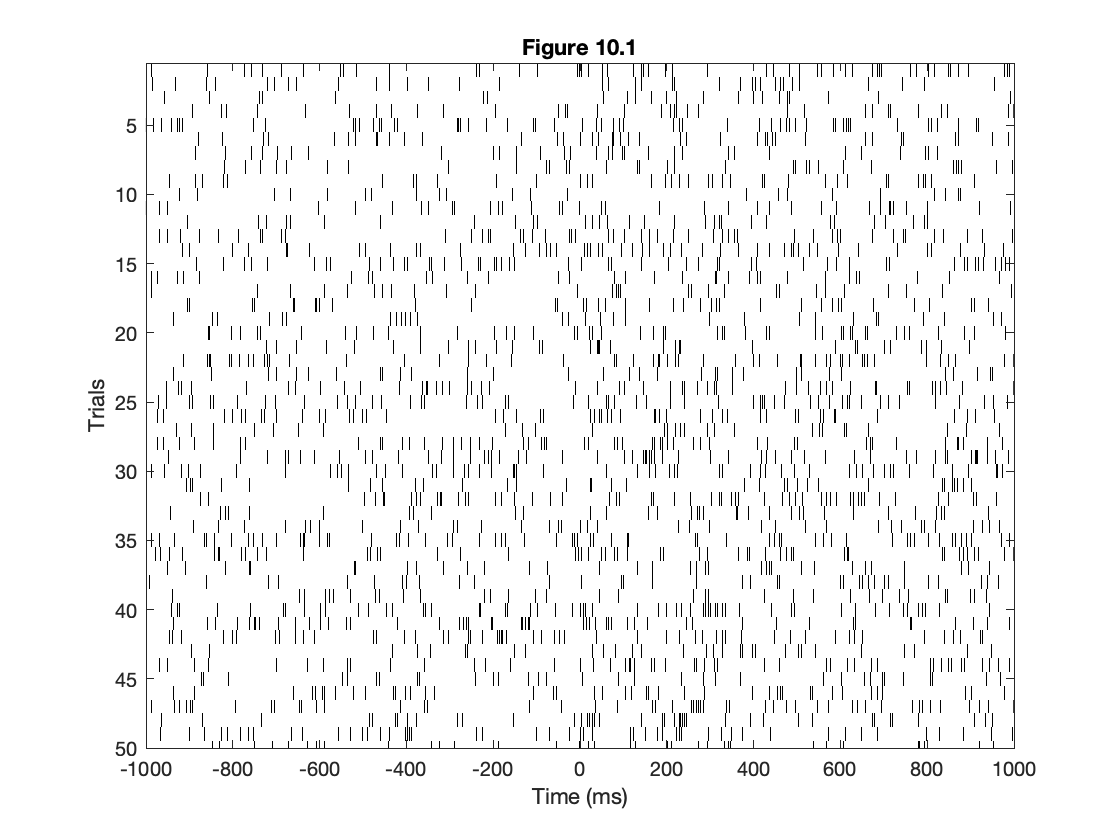

In [4]:
figure
imagesc(t, 1:50, train) %Construct a rastergram.
colormap(1 - gray); %...and change the colormap.
xlim([-1000, 1000])
ylim([0.5 50])
xlabel('Time (ms)')
ylabel('Trials')
title('Figure 10.1')


## Figure 10.2


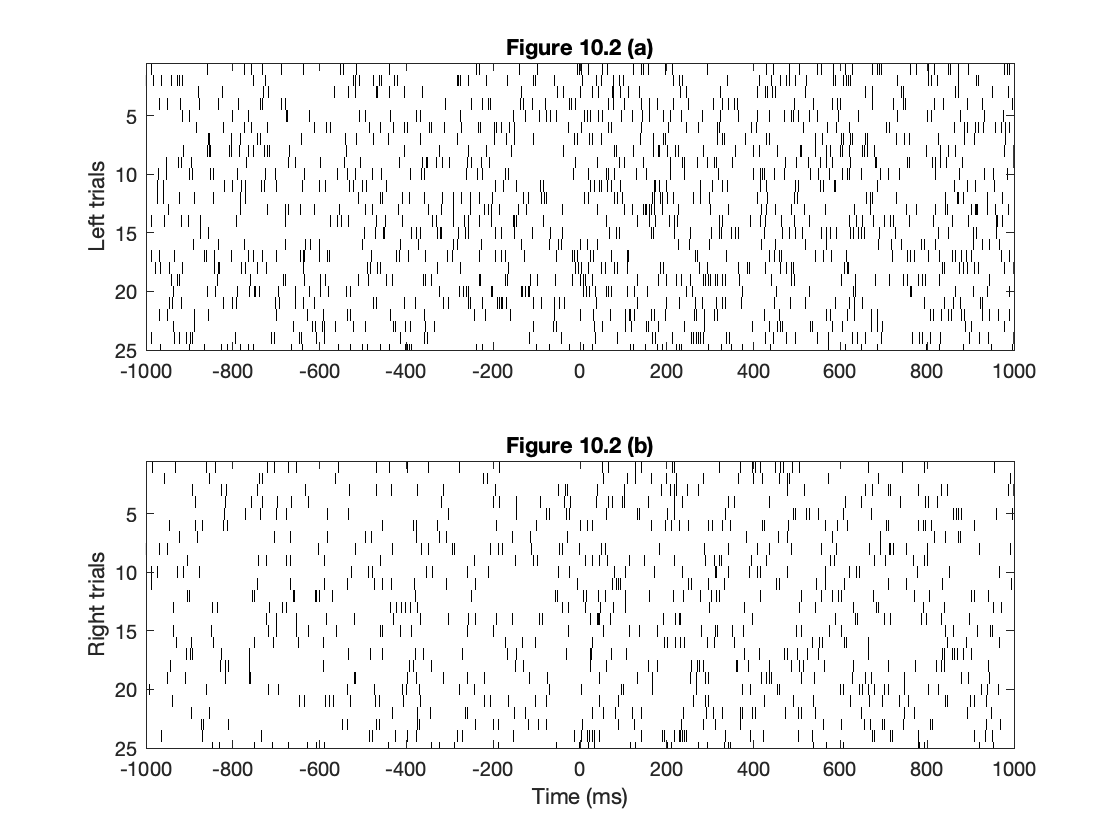

In [5]:
Ltrials = find(direction == 0); %Find left trials,
Rtrials = find(direction == 1); %...and right trials.

figure
subplot(2, 1, 1)
imagesc(t, 1:25, train(Ltrials, :)) %Image left trials,
colormap(1 - gray)
xlim([-1000, 1000])
ylim([0.5 25])
ylabel('Left trials')
title('Figure 10.2 (a)')

subplot(2, 1, 2)
imagesc(t, 1:25, train(Rtrials, :)) %...and right trials.
colormap(1 - gray)
xlim([-1000, 1000])
ylim([0.5 25])
xlabel('Time (ms)')
ylabel('Right trials')
title('Figure 10.2 (b)')


### Figure 10.3


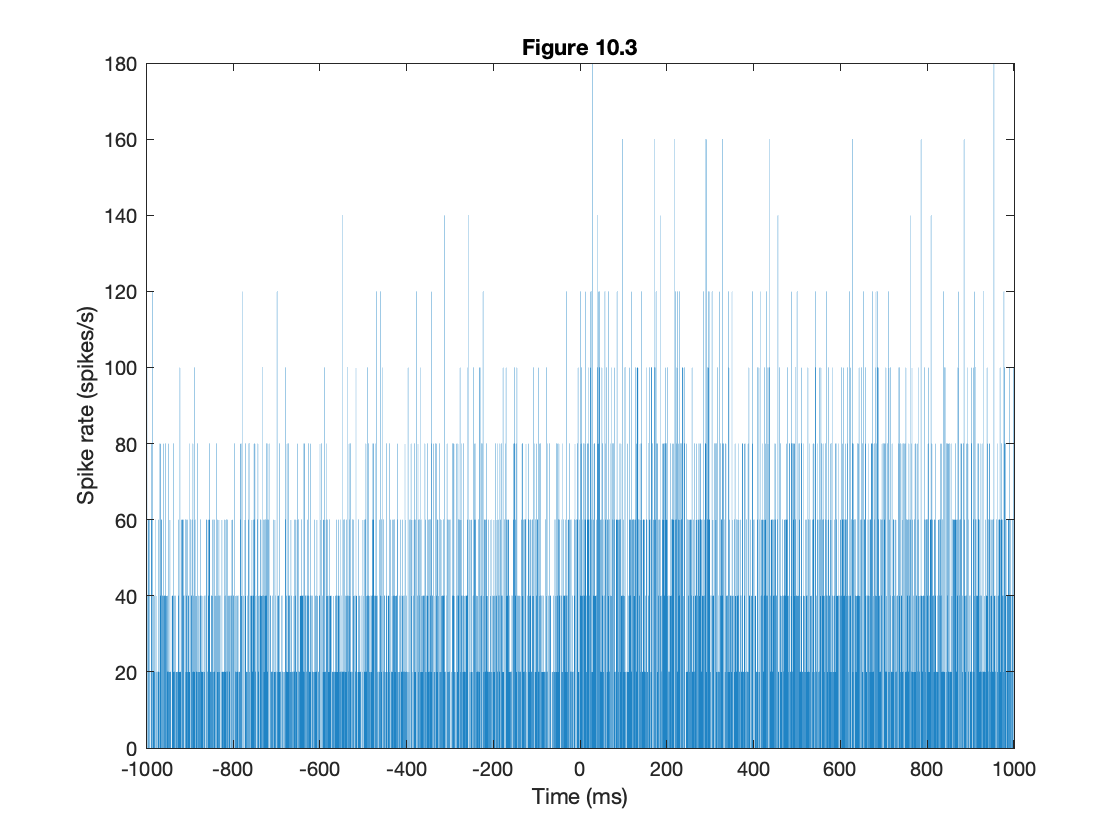

In [6]:
[spiketimes spiketrials] = find(train'); %Find when spikes occur,
PSTH = hist(spiketimes, 1:2000) / 50/1e-3; %... compute histogram.

figure
bar(t, PSTH); %Display the PSTH.
xlabel('Time (ms)')
ylabel('Spike rate (spikes/s)')
title('Figure 10.3')


### Figure 10.4


### Figure 10.5


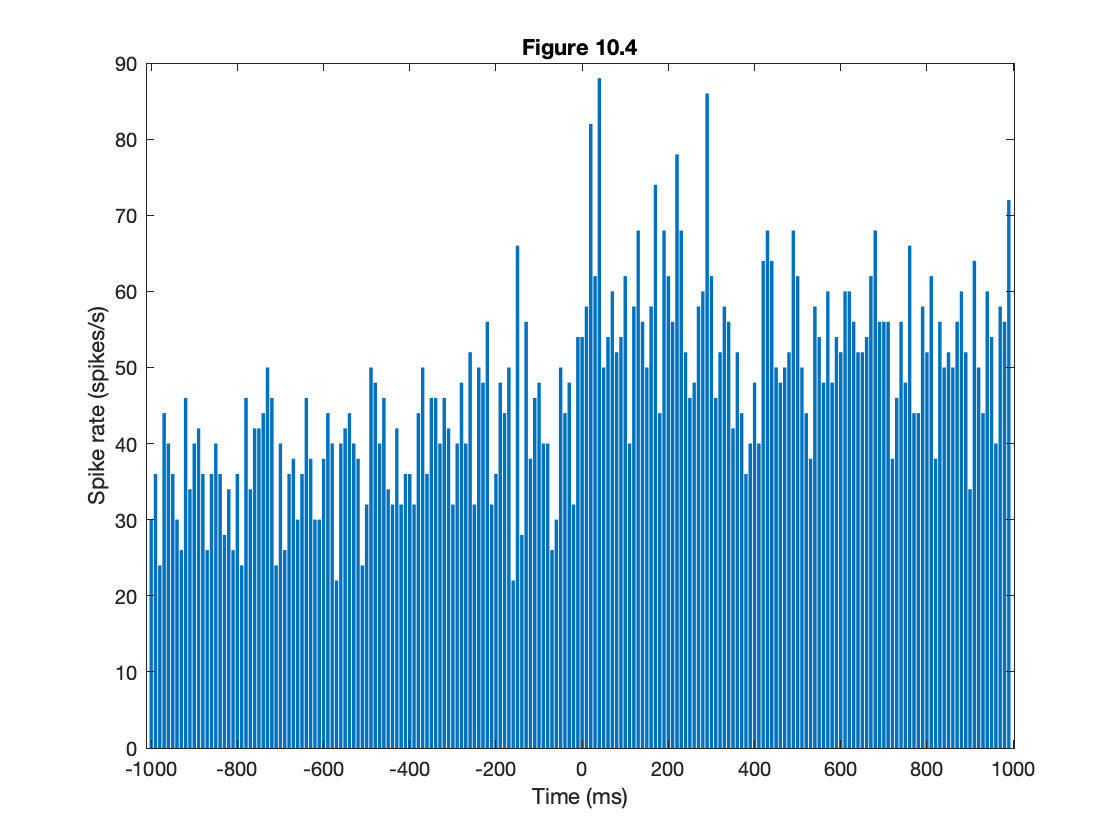

In [7]:
PSTH10 = hist(spiketimes, 1:10:2000); %Compute histogram.

figure
bar(t(1:10:2000), PSTH10 / 50/10 * 1000); %...and display PSTH.
xlabel('Time (ms)')
ylabel('Spike rate (spikes/s)')
title('Figure 10.4')


In [8]:
i_plan = find(t < 0); %Indices for planning.
i_move = find(t >= 0); %Indices for movement.

% Compute the average spike rate,
PlanRate = mean(mean(train(:, i_plan))) / 1e-3; %...during planning,
MoveRate = mean(mean(train(:, i_move))) / 1e-3; %...during movement.
fprintf('Planning rate: %.4f spikes/s\n', PlanRate);
fprintf('Movement rate: %.4f spikes/s\n', MoveRate);


Planning rate: 38.9600 spikes/s
Movement rate: 54.9600 spikes/s


In [9]:
Ltrials = find(direction == 0); %Find left trials,
Rtrials = find(direction == 1); %... and right trials.
LRate = mean(mean(train(Ltrials, :))) / 1e-3; %... and compute rates.
RRate = mean(mean(train(Rtrials, :))) / 1e-3;
fprintf('Left rate: %.4f spikes/s\n', LRate);
fprintf('Right rate: %.4f spikes/s\n', RRate);


Left rate: 58.6600 spikes/s
Right rate: 35.2600 spikes/s


### Figure 10.6


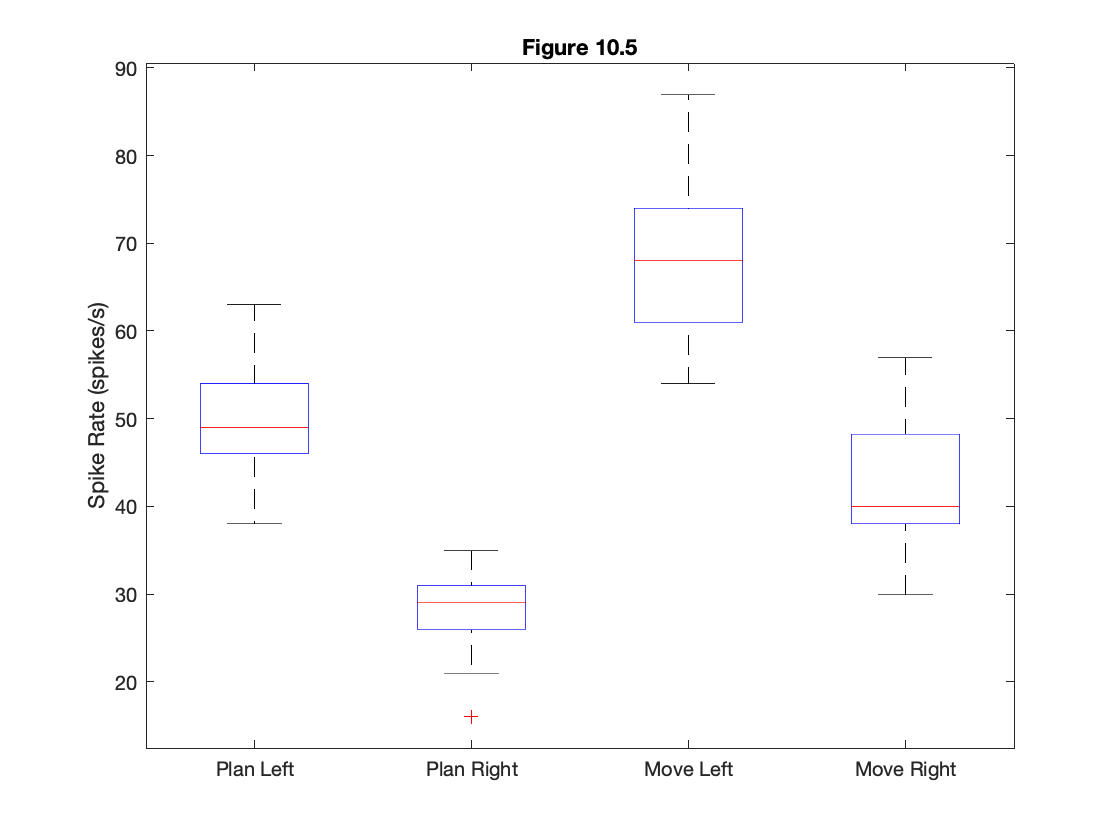

In [10]:
PlanL = sum(train(Ltrials, i_plan), 2); %Firing rate L, planning.
PlanR = sum(train(Rtrials, i_plan), 2); %Firing rate R, planning.
MoveL = sum(train(Ltrials, i_move), 2); %Firing rate L, movement.
MoveR = sum(train(Rtrials, i_move), 2); %Firing rate R, movement.

figure
boxplot([PlanL PlanR MoveL MoveR], ... %Display results.
    'labels', {'Plan Left', 'Plan Right', 'Move Left', 'Move Right'});
ylabel('Spike Rate (spikes/s)')
title('Figure 10.5')


### Figure 10.6


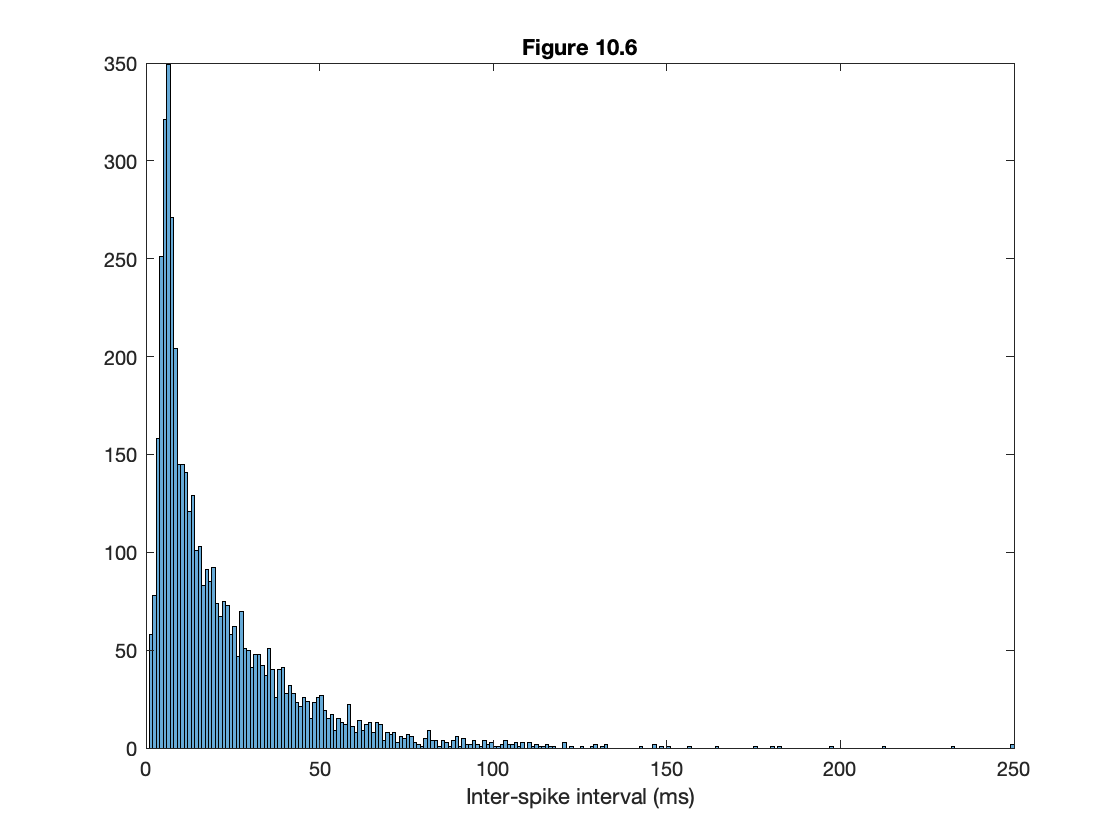

In [11]:
ISIs = diff(spiketimes); %Determine ISIs for all time & trials.
ISIs = ISIs(find(ISIs > 0)); %Remove spurious values between trials,

figure
histogram(ISIs, 0:250) %...and display results.
xlim([0 250])
xlabel('Inter-spike interval (ms)')
title('Figure 10.6')


### Figure 10.7


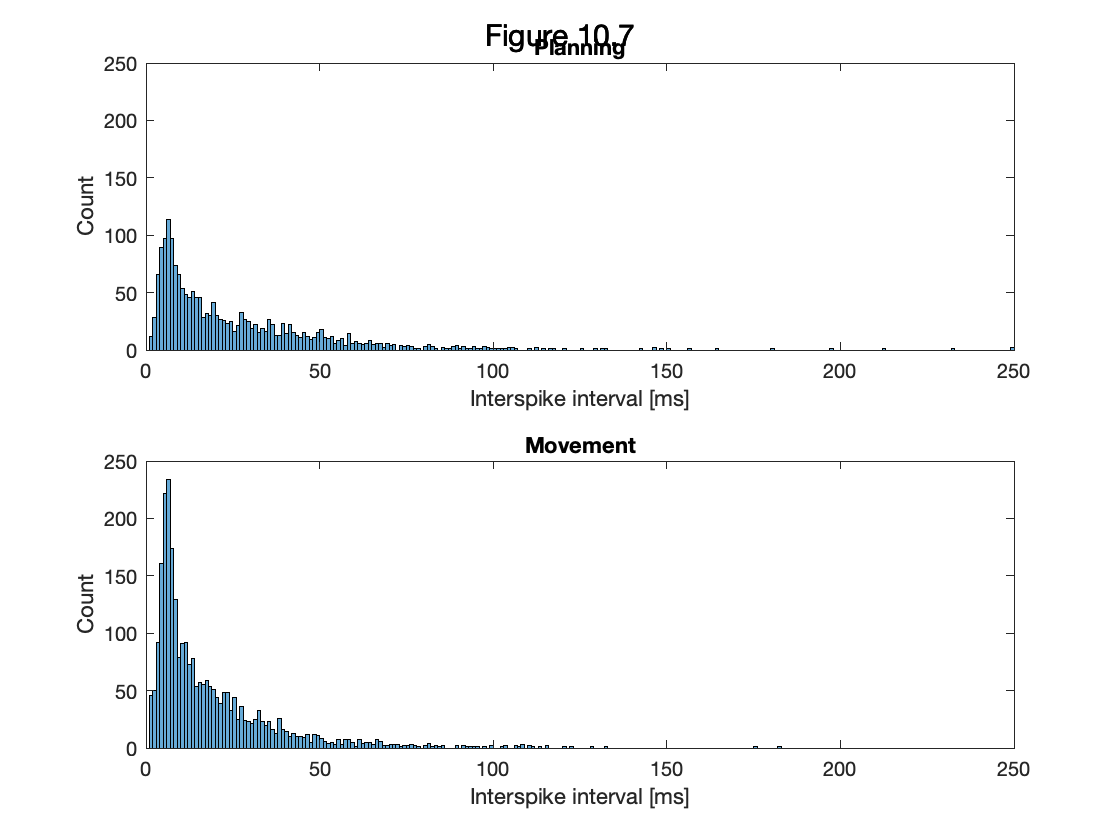

In [12]:
% In the planning period,				%...find spikes,
[spiketimesPlan spiketrials] = find(train(:, i_plan)');
PlanISIs = diff(spiketimesPlan); %...compute ISIs,
PlanISIs = PlanISIs(find(PlanISIs > 0)); %...drop spurious ones,

figure
subplot(211)
histogram(PlanISIs, 0:250) %...and plot it,
xlim([0 250])
ylim([0 250])
xlabel('Interspike interval [ms]') %...with axes labelled.
ylabel('Count')
title('Planning')

% In the movement period,				%...find spikes,
[spiketimesMove spiketrials] = find(train(:, i_move)');
MoveISIs = diff(spiketimesMove); %...compute ISIs,
MoveISIs = MoveISIs(find(MoveISIs > 0)); %...drop spurious ones,

subplot(212)
histogram(MoveISIs, 0:250) %...and plot it,
xlim([0 250])
ylim([0 250])
xlabel('Interspike interval [ms]') %...with axes labelled.
ylabel('Count')
title('Movement')

sgtitle('Figure 10.7') %...and a title for the figure.


## Step 2


### Figure 10.8


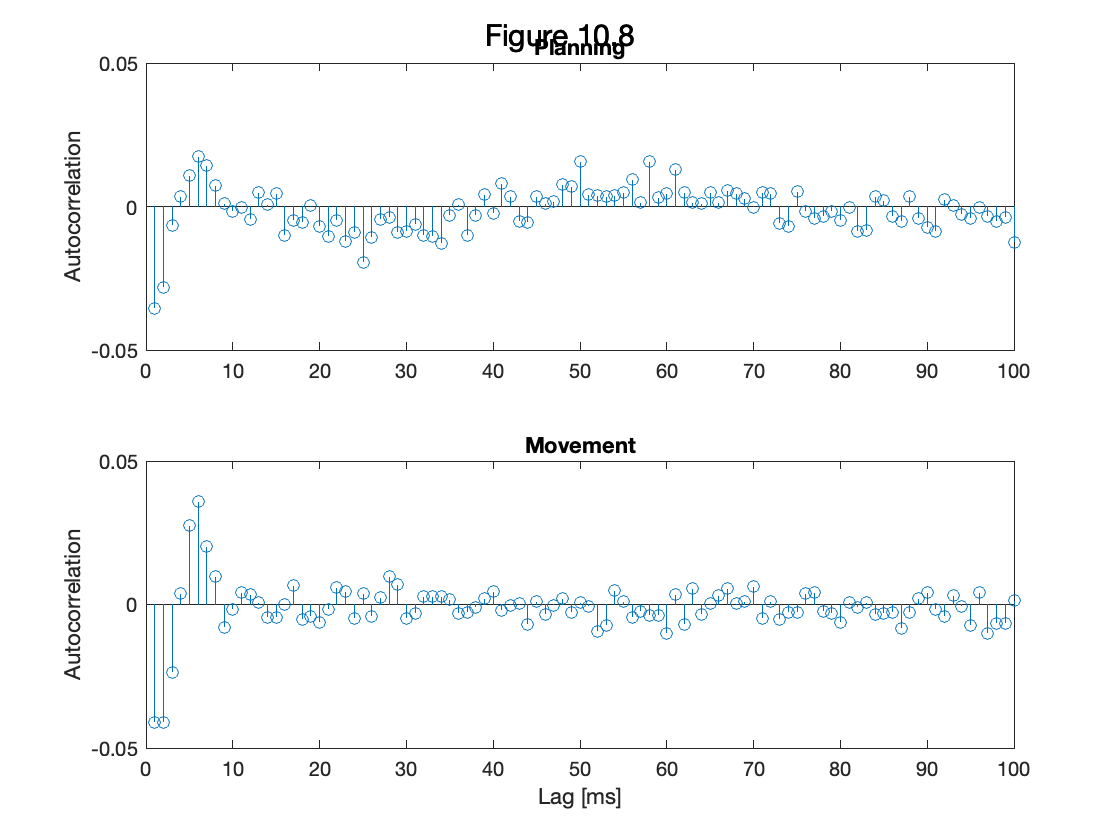

In [13]:
acf1 = zeros(50, 1999); % Preallocate ACF matrices.
acf2 = zeros(50, 1999); % ...for planning and movement.

for k = 1:50 %For each trial,
    plan = train(k, i_plan); %...get planning data,
    move = train(k, i_move); %...get movement data,
    acf1(k, :) = xcorr(plan - mean(plan), 'coeff'); %...compute ACFs,
    acf2(k, :) = xcorr(move - mean(move), 'coeff');
end %...and plot results,

figure
subplot(211)
stem(1:100, mean(acf1(:, 1001:1100)));
xlim([0 100])
ylim([- .05 .05])
ylabel('Autocorrelation') %... with axes labelled.
title('Planning')

subplot(212)
stem(1:100, mean(acf2(:, 1001:1100)));
xlim([0 100])
ylim([- .05 .05])
xlabel('Lag [ms]')
ylabel('Autocorrelation')
title('Movement')

sgtitle('Figure 10.8') %...and a title for the figure.


### Figure 10.10


In [14]:
% Set the parameters of the MTM.
TW = 4; %Choose time-bandwidth product of 4.
ntapers = 2 * TW - 1; %...which sets the # of tapers.
params.Fs = 1000; %Define sampling frequency,
params.tapers = [TW, ntapers]; %...time-band product,# tapers.
params.fpass = [0 500]; %Define frequency range to examine.
params.trialave = 1; %Perform trial averaging.

% Compute the coherence during planning & movement.
SPlan = mtspectrumpb(train(:, i_plan)', params);
[SMove, f] = mtspectrumpb(train(:, i_move)', params);


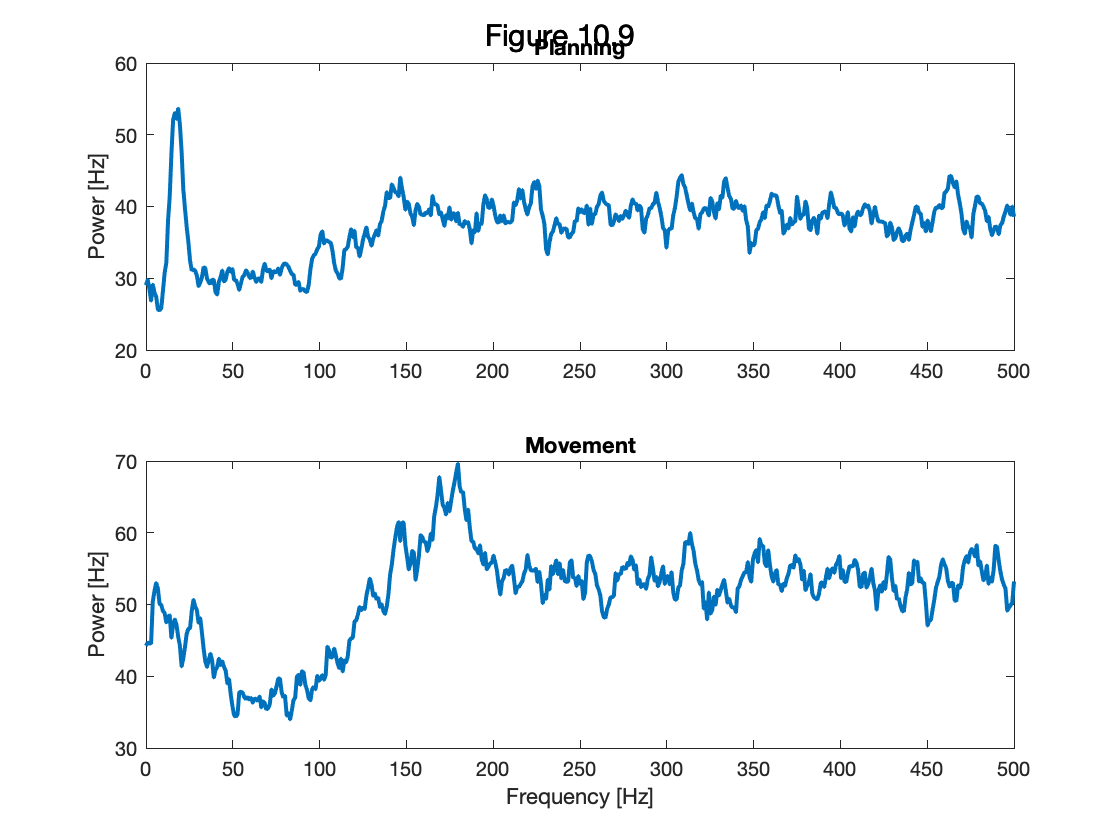

In [15]:
% Plot the spectra ... with axes labelled.
figure
subplot(211)
plot(f, SPlan, 'LineWidth', 2)
xlim([0 500])
ylim([20 60])
ylabel('Power [Hz]')
title('Planning')

subplot(212)
plot(f, SMove, 'LineWidth', 2)
xlim([0 500])
ylim([30 70])
xlabel('Frequency [Hz]')
ylabel('Power [Hz]')
title('Movement')

sgtitle('Figure 10.9') %...and a title for the figure.


### Figure 10.11


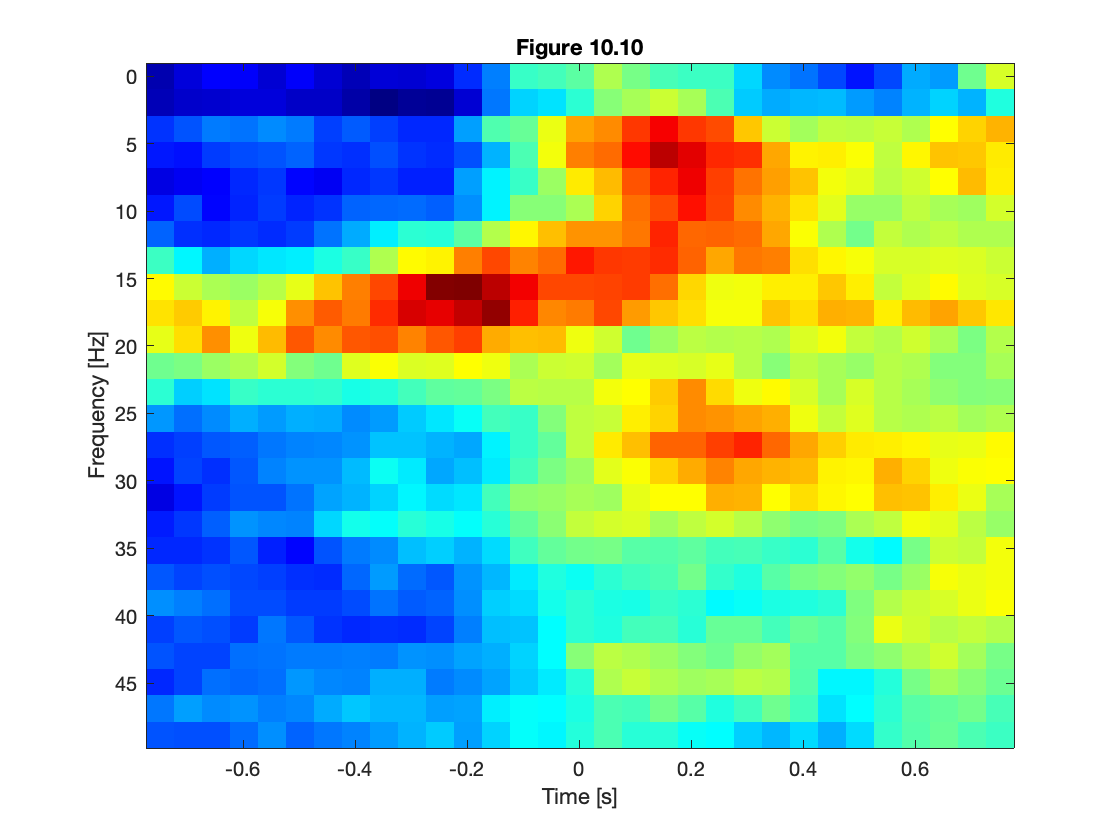

In [16]:
% Set the parameters of the MTM.
movingwin = [.5 .05]; %Define window duration & step size,
params.fpass = [0 50]; %...frequency range to examine,
params.tapers = [2 3]; %...time-band product, # tapers.
[S, T, F] = mtspecgrampb(train', movingwin, params); %Get spectrogram,
T = T + t(1) / 1000; %Set time axis,

figure
imagesc(T, F, S') %...and display it,
colormap(jet)
xlabel('Time [s]') %...with axes labelled.
ylabel('Frequency [Hz]')
title('Figure 10.10')


## Step 3


In [17]:
K = 50; %# trials.
T0 = length(t); %# time points.
Imove = ones(K, 1) * [zeros(1, T0 / 2) ones(1, T0 / 2)]; %Move indicator.
Imove = reshape((Imove)', K * T0, 1); %Reshape indicator
y = reshape(train', K * T0, 1); %Reshape spikes.
[b1, dev1, stats1] = glmfit(Imove, y, 'poisson'); %Fit Model 1.
fprintf('Firing rate of planning: %.4f spikes/ms\n', exp(b1(1)))
fprintf('Firing rate of movement: %.4f spikes/ms\n', exp(b1(2)))


Firing rate of planning: 0.0390 spikes/ms
Firing rate of movement: 1.4107 spikes/ms


In [18]:
% Compute CI for firing rate modulation during movement period,
CI_lower = exp(b1(2) - 2 * stats1.se(2)); %...lower CI, a more accurate constant should be 1.96
CI_upper = exp(b1(2) + 2 * stats1.se(2)); %...upper CI.
fprintf('95%% CI for movement modulation: [%.4f, %.4f] spikes/ms\n', ...
    CI_lower, CI_upper);

pval = stats1.p(2); % p-value from Wald test.
fprintf('p-value from Wald test: %.4f\n', pval);


95% CI for movement modulation: [1.3295, 1.4968] spikes/ms
p-value from Wald test: 0.0000


### Figure 10.12


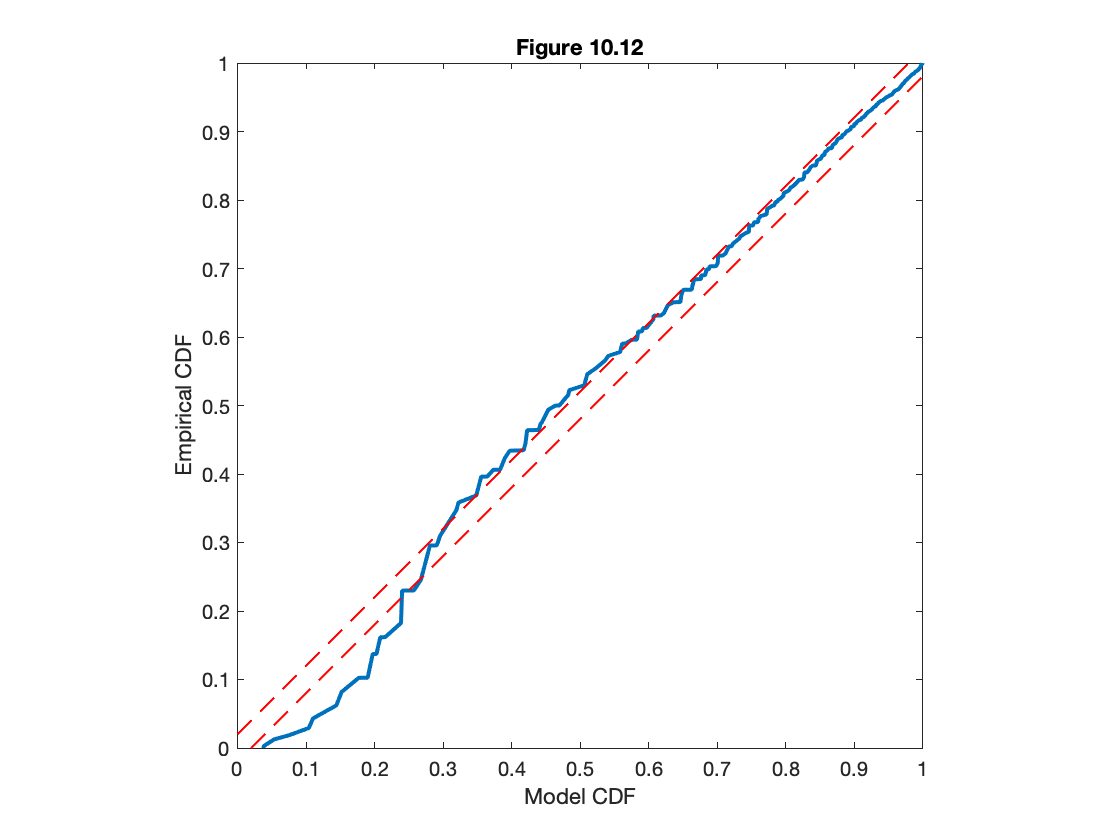

In [19]:
lambda1 = exp(b1(1) + b1(2) * Imove); %Firing rate of Model 1.
spikeindex = find(y); %Find spikes,
N = length(spikeindex); %...and total # spikes.
Z = zeros(N, 1); %Preallocate rescaled times.
Z(1) = sum(lambda1(1:spikeindex(1))); %1st rescaled waiting time,

for i = 2:N, %...and the rest.
    Z(i) = sum(lambda1(spikeindex(i - 1) + 1:spikeindex(i)));
end

[eCDF, zvals] = ecdf(Z); %Empirical CDF at z values.
mCDF = 1 - exp(-zvals); %Model CDF at z values.

figure
plot(mCDF, eCDF, 'LineWidth', 2) %Create KS-plot.
hold on %Freeze graphics window.
plot([0 1], [0 1] + 1.36 / sqrt(N), 'r--', 'LineWidth', 1) %Upper confidence bound.
plot([0 1], [0 1] - 1.36 / sqrt(N), 'r--', 'LineWidth', 1) %Lower confidence bound.
axis([0 1 0 1]) %Fix axes,
axis square
xlabel('Model CDF') %Label the axes.
ylabel('Empirical CDF')
title('Figure 10.12')


## Refining the model: movement direction


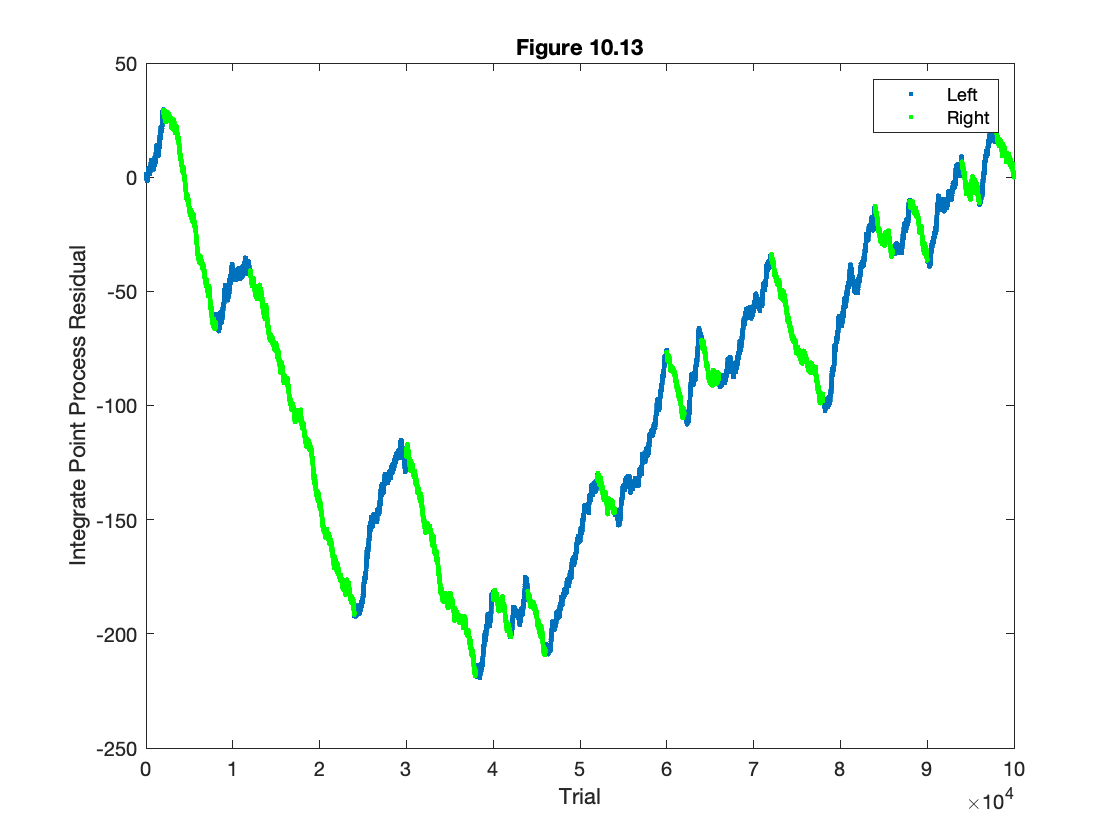

In [20]:
% Create indicator for trial movement direction.
xdir = reshape((direction * ones(1, T0))', K * T0, 1);
i0 = find(xdir == 0); %Left movement trial.
i1 = find(xdir == 1); %Right movement trial.
R = cumsum(stats1.resid); %Cumulative sum of Model 1 residuals.

figure
h1 = plot(i0, R(i0), '.'); %Plot residuals for L trials,
hold on %...freeze graphics,
h2 = plot(i1, R(i1), 'g.'); %...and plot residuals for R trials,
legend([h1 h2], 'Left', 'Right')
xlabel('Trial') %...label axes.
ylabel('Integrate Point Process Residual')
title('Figure 10.13')


In [21]:
% Fit Model 2, and return estimates and useful statistics.
[b2, dev2, stats2] = glmfit([Imove xdir], y, 'poisson');
fprintf('Firing rate of planning: %.4f spikes/ms\n', exp(b2(1)))
fprintf('Firing rate of movement: %.4f spikes/ms\n', exp(b2(2)))

pval = stats2.p(3); %Significance of Model 2 direction parameter.


Firing rate of planning: 0.0487 spikes/ms
Firing rate of movement: 1.4107 spikes/ms


## Figure 10.14


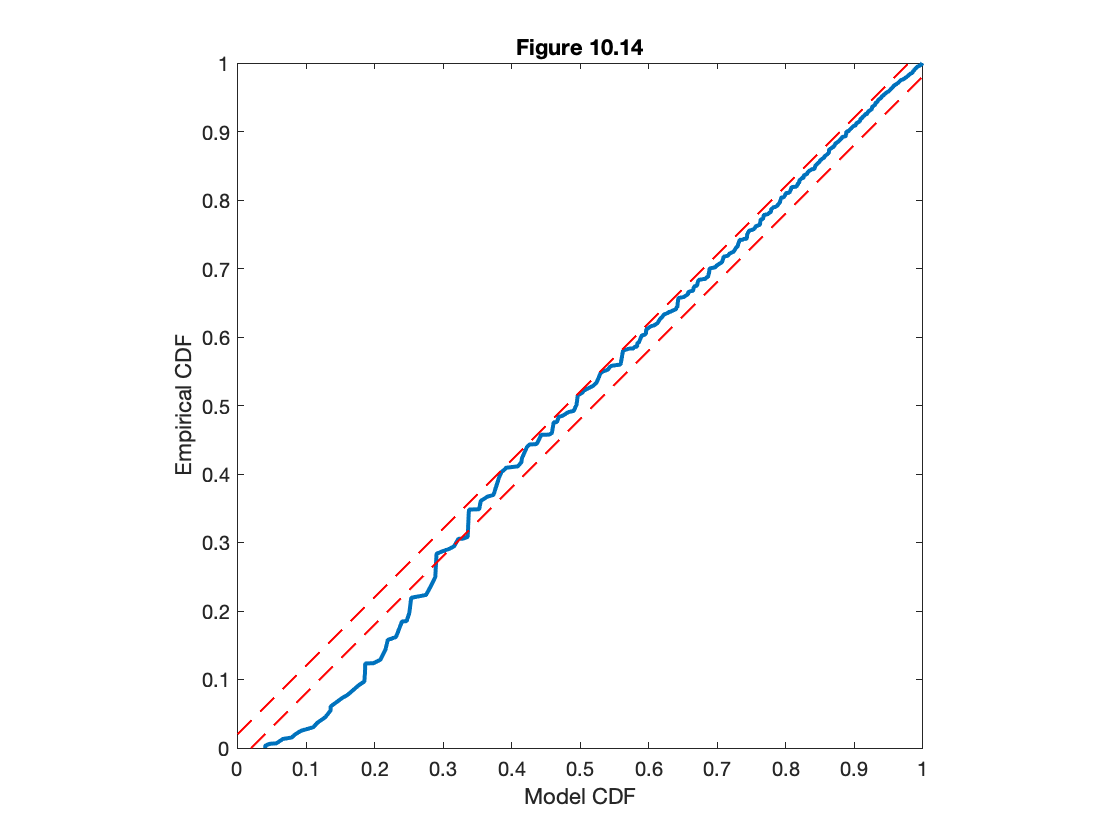

In [22]:
lambda2 = exp(b2(1) + b2(2) * Imove + b2(3) * xdir); %Evaluate Model 2.
Z = zeros(N, 1); %Preallocate rescaled times.
Z(1) = sum(lambda2(1:spikeindex(1))); %1st rescaled waiting time,

for i = 2:N %... and the rest.
    Z(i) = sum(lambda2(spikeindex(i - 1) + 1:spikeindex(i)));
end

[eCDF, zvals] = ecdf(Z); %Empirical CDF.
mCDF = 1 - exp(-zvals); %Model CDF.

figure
plot(mCDF, eCDF, 'LineWidth', 2) %Create KS-plot.
hold on %Freeze graphics.
plot([0 1], [0 1] + 1.36 / sqrt(N), 'r--', 'LineWidth', 1) %Upper confidence bound.
plot([0 1], [0 1] - 1.36 / sqrt(N), 'r--', 'LineWidth', 1) %Lower confidence bound.
axis([0 1 0 1]) %Fix axes,
axis square
xlabel('Model CDF') %Label the axes.
ylabel('Empirical CDF')
title('Figure 10.14')


## Refining the model: history dependence


In [23]:
ord = 70; %Set the model order.

T1 = T0 - ord; %Update # time points.
%Redefine observable & predictors to support history dependence.
y = reshape(train(:, ord + 1:end)', K * T1, 1); %Data.
xdir = reshape((direction * ones(1, T1))', K * T1, 1); %Direction.
Imove = ones(K, 1) * [zeros(1, T0 / 2 - ord) ones(1, T0 / 2)]; %Period,
Imove = reshape((Imove)', K * T1, 1); %...reshaped.
xHist = []; %Create the history predictor,

for i = 1:ord %...for each step in past.
    xHist = cat(2, xHist, reshape(train(:, ord + 1 - i:end - i)', K * T1, 1));
end


In [24]:
% Fit Model 3, with history dependence.
[b3, dev3, stats3] = glmfit([Imove xdir xHist], y, 'poisson');
fprintf('Firing rate of planning: %.4f spikes/ms\n', exp(b3(1)))
fprintf('Firing rate of movement: %.4f spikes/ms\n', exp(b3(2)))


Firing rate of planning: 0.0475 spikes/ms
Firing rate of movement: 1.3913 spikes/ms


In [25]:
% Fit Model 4, with history dependence in each period.
[b4, dev4, stats4] = glmfit([Imove xdir ... %Period & direction.
                                 ((1 - Imove) * ones(1, ord)) .* xHist ... %History in planning.
                                 (Imove * ones(1, ord)) .* xHist], y, 'poisson'); %History in movement.

% Examine first three exponentiated parameters of Model 4.
fprintf('Firing rate of planning exp(b4(1)): %.4f spikes/ms\n', exp(b4(1)))
fprintf('Firing rate of movement exp(b4(2)): %.4f spikes/ms\n', exp(b4(2)))
fprintf('Firing rate of planning modulation exp(b4(3)): %.4f spikes/ms\n', exp(b4(3))) %..and the modulation.


Firing rate of planning exp(b4(1)): 0.0480 spikes/ms
Firing rate of movement exp(b4(2)): 1.3819 spikes/ms
Firing rate of planning modulation exp(b4(3)): 0.6063 spikes/ms


### Figure 10.15


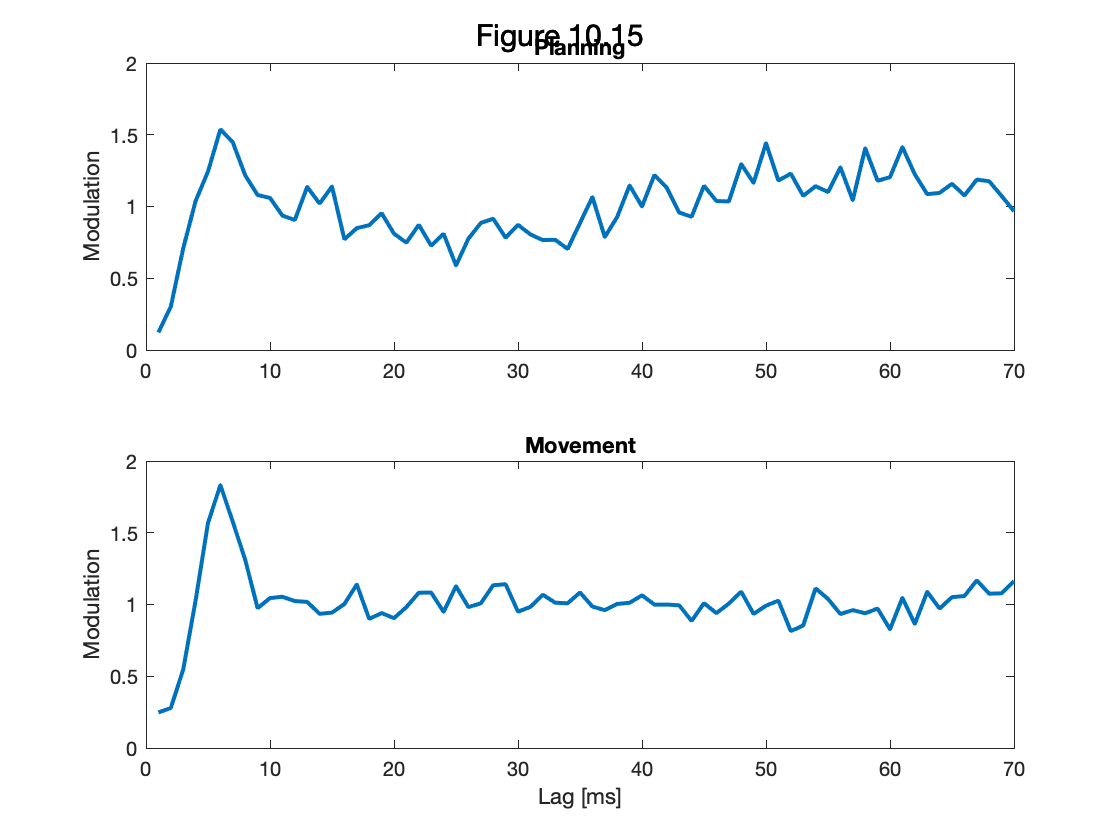

In [26]:
figure
subplot(211)
plot(1:ord, exp(b4(4:ord + 3)), 'LineWidth', 2) %Planning,
ylim([0 2])
ylabel('Modulation') %..axes labelled.
title('Planning')

subplot(212)
plot(1:ord, exp(b4(ord + 4:end)), 'LineWidth', 2) %Movement,
ylim([0 2])
xlabel('Lag [ms]') %..axes labelled.
ylabel('Modulation')
title('Movement')

sgtitle('Figure 10.15') %...and a title for the figure.


### Figure 10.16


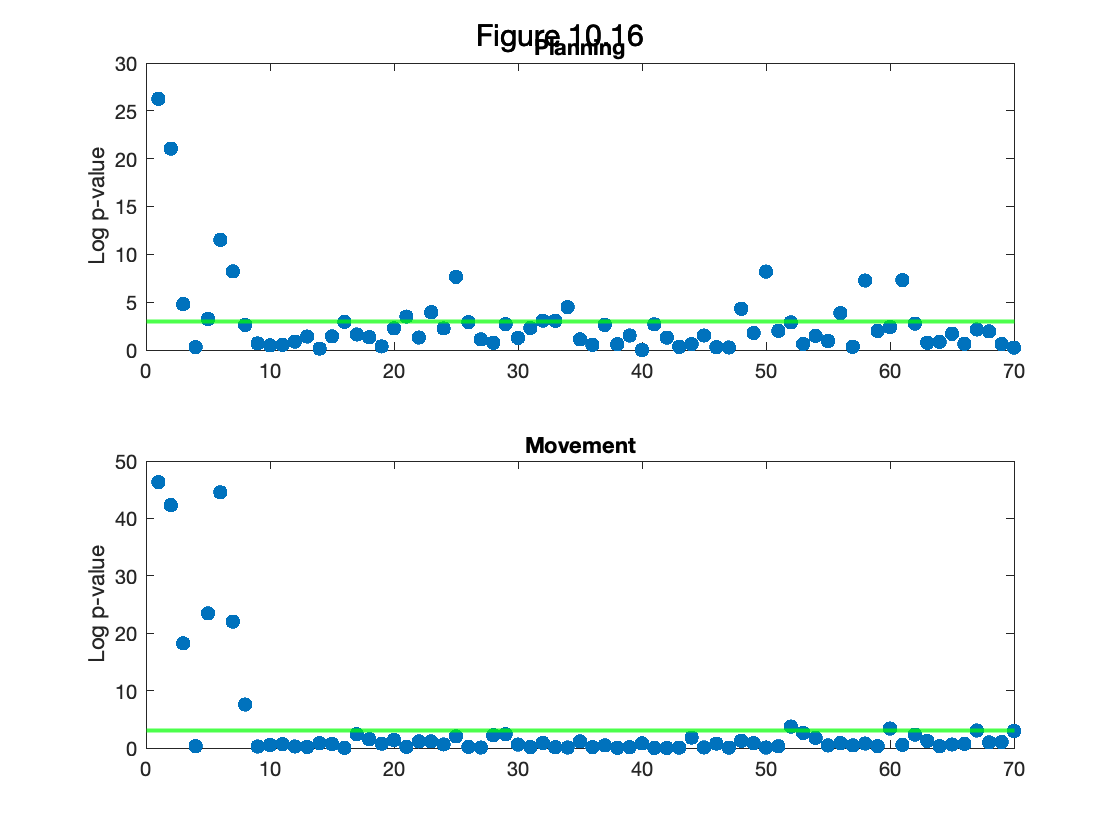

In [27]:
figure
subplot(211)
plot(1:ord, -log(stats4.p(4:3 + ord)), '.', 'MarkerSize', 20) %p-values for Planning,
hold on %...freeze graphics,
yline(-log(.05), 'g', 'LineWidth', 2); %...draw threshold,
ylim([0 30])
ylabel('Log p-value')
title('Planning')

subplot(212)
plot(1:ord, -log(stats4.p(4 + ord:end)), '.', "MarkerSize", 20) %p-values for Movement
hold on %...freeze graphics,
yline(-log(.05), 'g', 'LineWidth', 2); %...draw threshold,
ylim([0 50])
ylabel('Log p-value')
title('Movement')

sgtitle('Figure 10.16') %...and a title for the figure.


In [28]:
pval = 1 - chi2cdf(dev3 - dev4, ord); %Compare two nested GLMs.
fprintf('p-value for Model 3 vs Model 4: %.4e\n', pval); %...and print p-value.


p-value for Model 3 vs Model 4: 2.3190e-08


### Figure 10.17


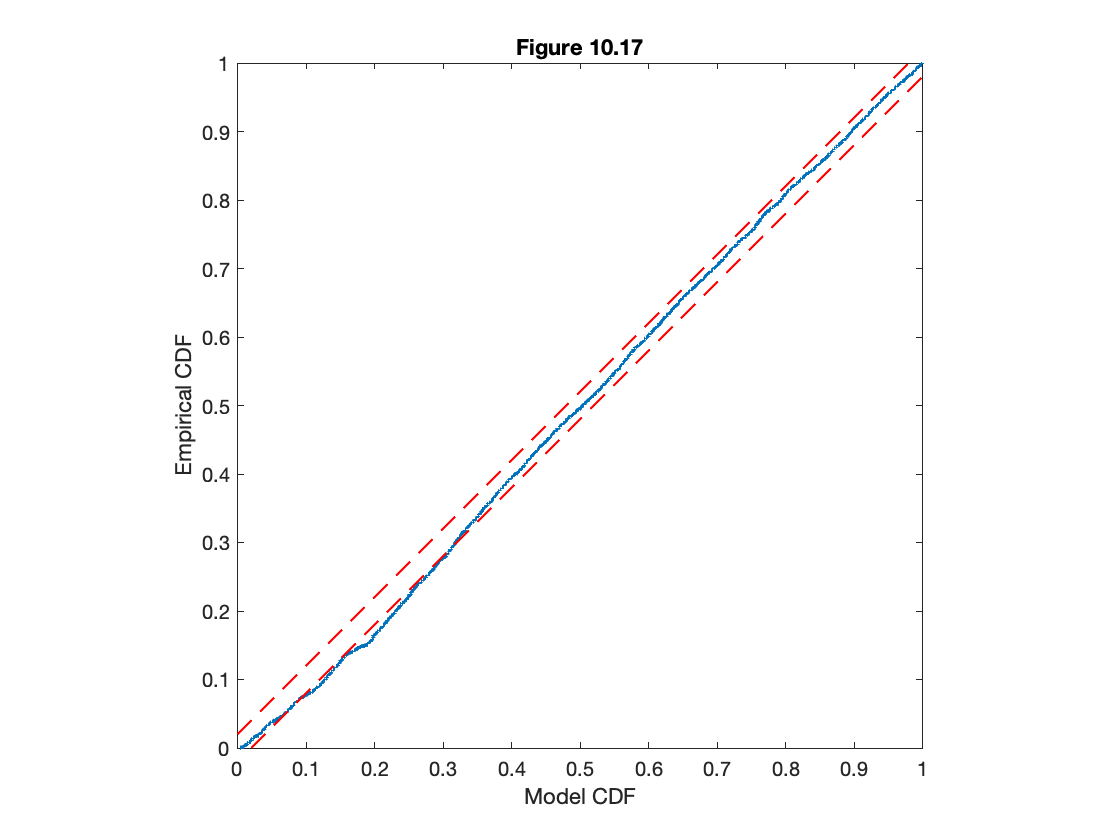

In [29]:
lambda4 = glmval(b4, [Imove xdir ... %Evaluate Model 4.
                          ((1 - Imove) * ones(1, ord)) .* xHist ...
                          (Imove * ones(1, ord)) .* xHist], 'log');
spikeindex = find(y); %Find spikes,
N = length(spikeindex); %...and total # spikes.
Z = zeros(N, 1); %Preallocate rescaled times.
Z(1) = sum(lambda4(1:spikeindex(1))); %1st rescaled waiting time,

for i = 2:N %... and the rest.
    Z(i) = sum(lambda4(spikeindex(i - 1) + 1:spikeindex(i)));
end

[eCDF, zvals] = ecdf(Z); %Empirical CDF.
mCDF = 1 - exp(-zvals); %Model CDF.

figure
plot(mCDF, eCDF, 'LineWidth', 2) %Create KS-plot.
hold on %Freeze graphics.
plot([0 1], [0 1] + 1.36 / sqrt(N), 'r--', 'linewidth', 1) %Upper confidence bound.
plot([0 1], [0 1] - 1.36 / sqrt(N), 'r--', 'linewidth', 1) %Lower confidence bound.
axis([0 1 0 1]) %Fix axes,
axis square
xlabel('Model CDF') %Label the axes.
ylabel('Empirical CDF')
title('Figure 10.17')


## Choice of model order


### Figure 10.18


In [30]:
maxord = 100; % Maximum model order.

% Redefine observable & predictors to support history dependence.
yplan = reshape(train(:, maxord + 1:T0 / 2)', K * (T0 / 2 - maxord), 1);
plandir = reshape((direction * ones(1, T0 / 2 - maxord))', ...
    K * (T0 / 2 - maxord), 1);
planHist = []; %Create the history predictor,
aic = zeros(maxord, 1); %...and preallocate AIC.

for i = 1:maxord %...for each step in past,
    planHist = cat(2, planHist, ... %...define history,
        reshape(train(:, maxord + 1 - i:T0 / 2 - i)', K * (T0 / 2 - maxord), 1));
    %..fit the model,
    [b0, dev0, stats0] = glmfit([plandir planHist], yplan, 'poisson');
    %...and compute the AIC.
    aic(i) = dev0 + 2 * length(b0);
end


Minimum AIC at order 62


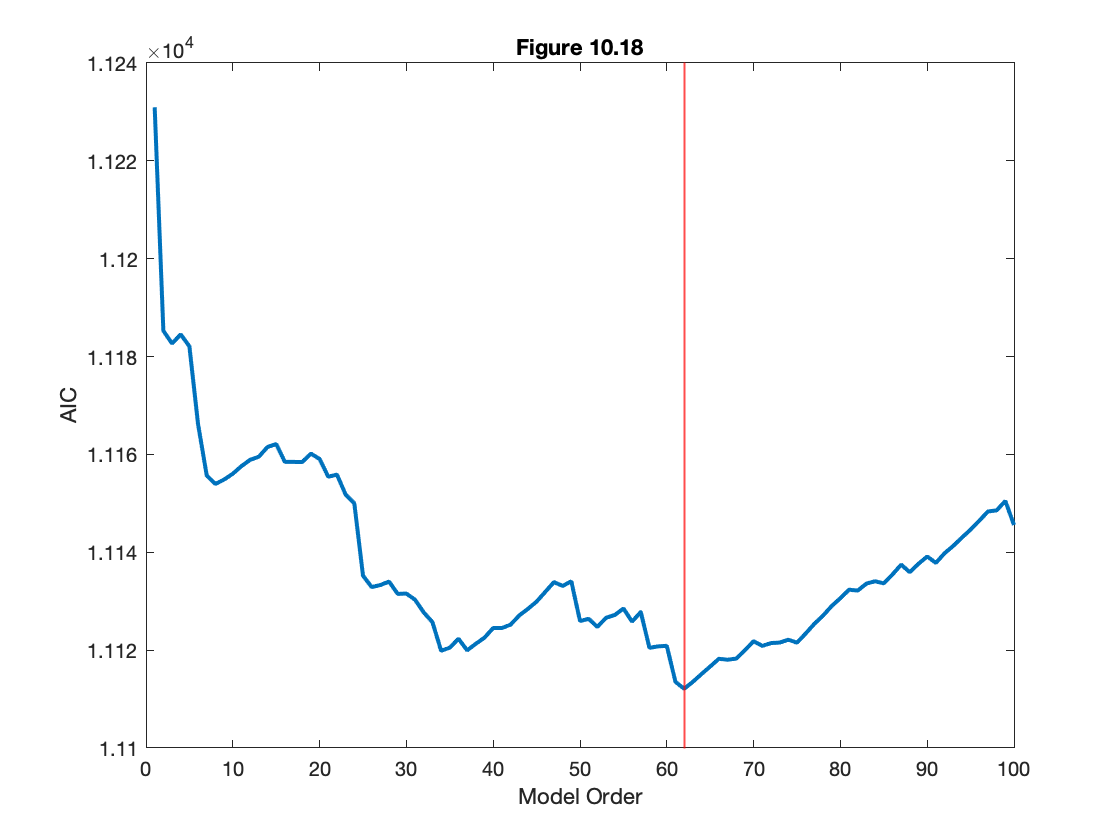

In [31]:
[~, minord] = min(aic); %Find the minimum AIC,
fprintf('Minimum AIC at order %d\n', minord);

figure
plot(1:maxord, aic, 'LineWidth', 2); %Plot the AIC,
hold on
xline(minord, 'r', 'LineWidth', 1); %...and mark the minimum.
xlabel('Model Order') %...with axes labelled,
ylabel('AIC')
title('Figure 10.18')


### Figure 10.19


In [32]:
C = zeros(ord, 8); %Preallocate Gaussian kernel matrix.

for i = 1:ord %Construct the Gaussian kernels.
    C(i, :) = normpdf(-5:10:ord, i, 5);
end

%Fit Model 5, with Gaussian kernel basis.
nparams = size(C, 2);
[b5, dev5, stats5] = glmfit( ...
    [Imove xdir ... %Period & direction.
     ((1 - Imove) * ones(1, nparams)) .* (xHist * C) ... %History in planning.
     (Imove * ones(1, nparams)) .* (xHist * C)], ... %History in movement.
    y, 'poisson');


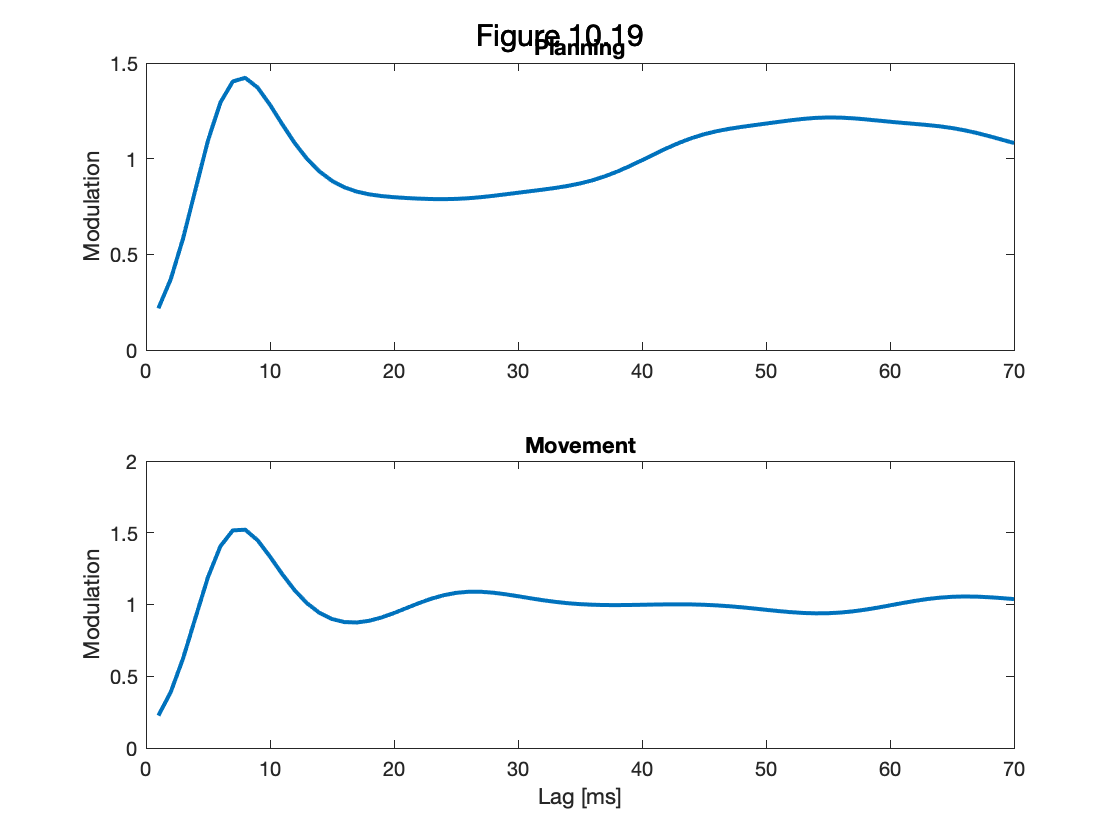

In [33]:
figure
subplot(211)
plot(1:ord, exp(C * b5(4:nparams + 3)), 'LineWidth', 2); %Planning,
ylim([0 1.5])
ylabel('Modulation') %..axes labelled.
title('Planning')

subplot(212)
plot(1:ord, exp(C * b5(nparams + 4:end)), 'LineWidth', 2); %Movement,
ylim([0 2])
xlabel('Lag [ms]') %..axes labelled.
ylabel('Modulation')
title('Movement')

sgtitle('Figure 10.19') %...and a title for the figure.


### Figure 10.20

In [34]:
lambda5 = glmval(b5, [Imove xdir ... %Evaluate Model 5.
                          ((1 - Imove) * ones(1, nparams)) .* (xHist * C) ...
                          (Imove * ones(1, nparams)) .* (xHist * C)], 'log');
spikeindex = find(y); %Find spikes,
N = length(spikeindex); %...and total # spikes.
Z = zeros(N, 1); %Preallocate rescaled times.
Z(1) = sum(lambda5(1:spikeindex(1))); %1st rescaled waiting time,

for i = 2:N %... and the rest.
    Z(i) = sum(lambda5(spikeindex(i - 1) + 1:spikeindex(i)));
end;

[eCDF, zvals] = ecdf(Z); %Empirical CDF.
mCDF = 1 - exp(-zvals); %Model CDF.


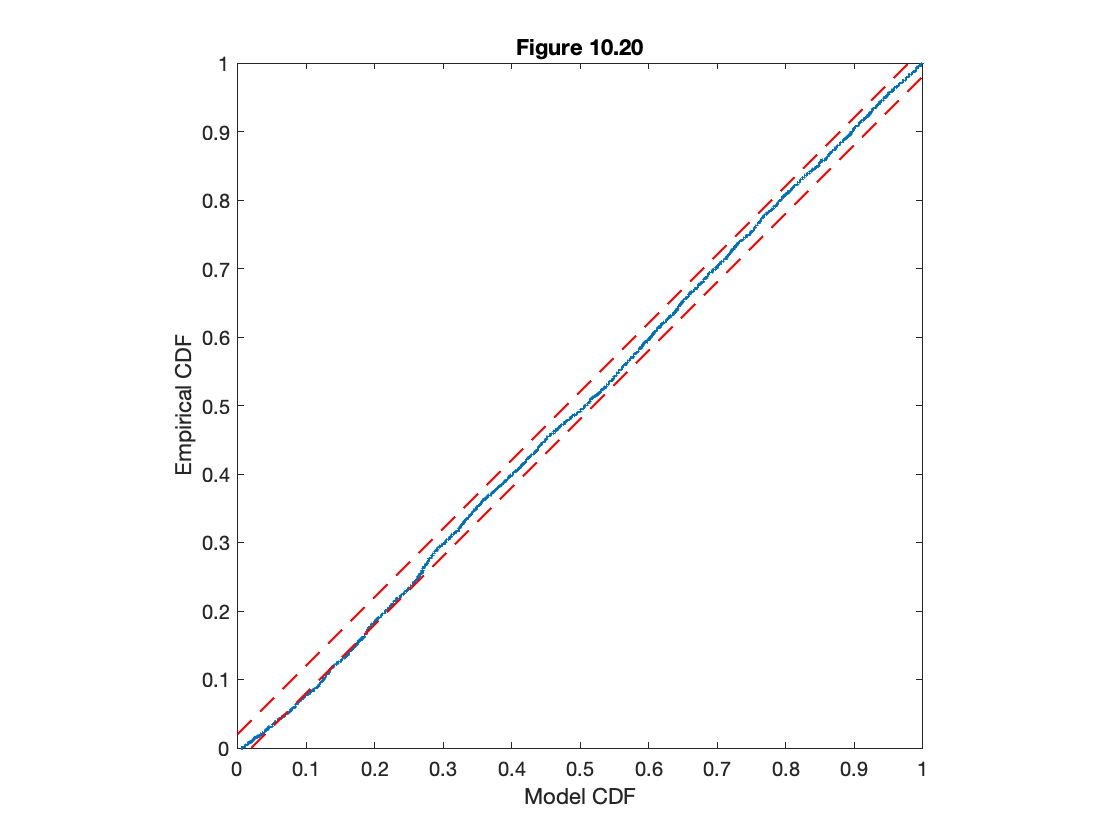

In [35]:
figure
plot(mCDF, eCDF, 'LineWidth', 2) %Create KS-plot.
hold on %Freeze graphics.
plot([0 1], [0 1] + 1.36 / sqrt(N), 'r--', 'LineWidth', 1) %Upper confidence bound.
plot([0 1], [0 1] - 1.36 / sqrt(N), 'r--', 'LineWidth', 1) %Lower confidence bound.
axis([0 1 0 1]) %Fix axes,
axis square
xlabel('Model CDF') %Label the axes.
ylabel('Empirical CDF')
title('Figure 10.20')


## Step 4

### Figure 10.21

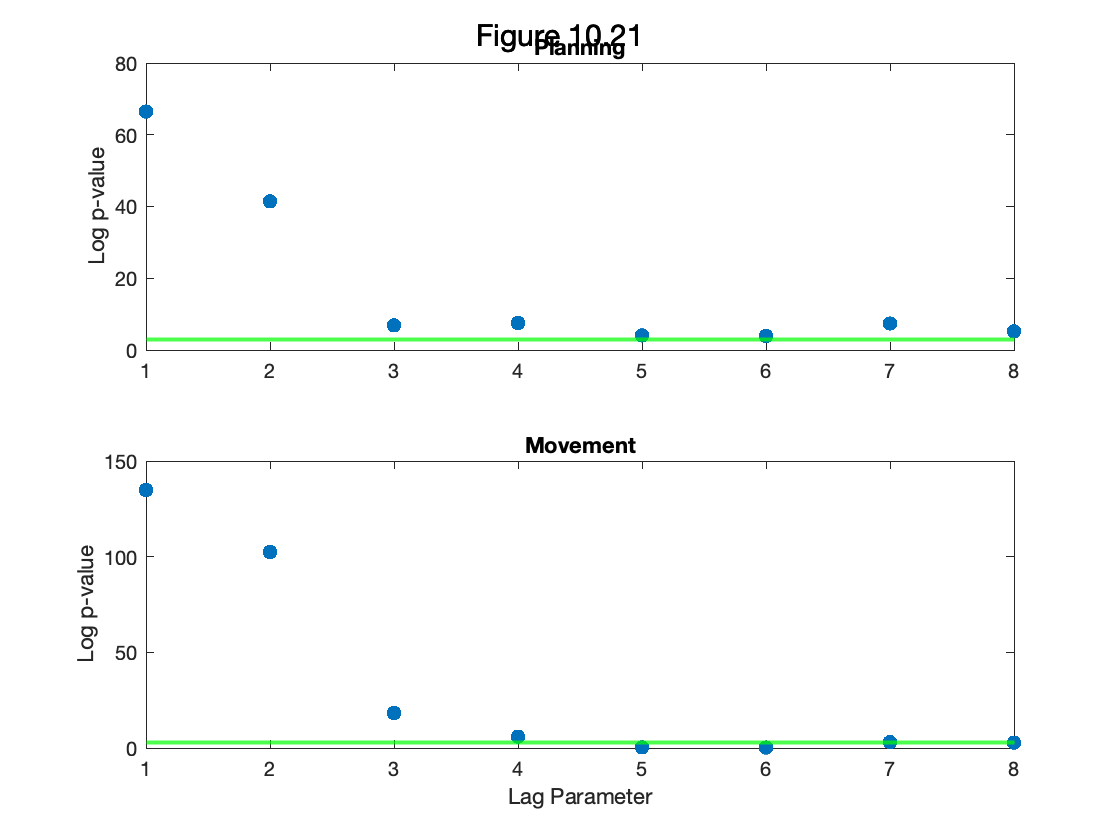

In [36]:
figure
subplot(211) %p-values for Planning,
plot(1:nparams, -log(stats5.p(4:3 + nparams)), '.', 'MarkerSize', 20)
hold on %...freeze graphics,
yline(-log(.05), 'g', 'LineWidth', 2) %...draw threshold,
ylabel('Log p-value')
title('Planning')

subplot(212) %p-values for Movement,
plot(1:nparams, -log(stats5.p(4 + nparams:end)), '.', 'MarkerSize', 20)
hold on %...freeze graphics,
yline(-log(.05), 'g', 'LineWidth', 2) %...draw threshold,
xlabel('Lag Parameter')
ylabel('Log p-value')
title('Movement')

sgtitle('Figure 10.21') %...and a title for the figure.


In [37]:
%Fit a reduced version of Model 5,
[b6, dev6, stats6] = glmfit([Imove xdir xHist * C], y, 'poisson');
fprintf('Firing rate of planning exp(b6(1)): %.4f spikes/ms\n', exp(b6(1)))
fprintf('Firing rate of movement exp(b6(2)): %.4f spikes/ms\n', exp(b6(2)))
fprintf('Firing rate of planning modulation exp(b6(3)): %.4f spikes/ms\n', exp(b6(3))) %...and the modulation.

p = 1 - chi2cdf(dev6 - dev5, nparams); %Compare Model 5 and reduction.
fprintf('p-value for Model 5 vs Model 6: %.4e\n', p); %...and print p-value.


Firing rate of planning exp(b6(1)): 0.0476 spikes/ms
Firing rate of movement exp(b6(2)): 1.3933 spikes/ms
Firing rate of planning modulation exp(b6(3)): 0.6065 spikes/ms
p-value for Model 5 vs Model 6: 3.3307e-16
